Analyzes previously smoothed frequency-magnitude data. It loads concolved .dat files, focusses on a user selected frequency range, detects meaningful peaks using height and prominend thresholds, calculates peak-to-peak spacing and peak widths, save peaks and width values and plots the detected peak locations for visual checking.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**def analyze_convolved_peaks** performs the main peak analysis for one frequncy-magnitude dataset within one selected frequency range. It first limits the data to the chosen range, then calculates height and prminence threshold based on the maximum magnitude in that range. It uses those thresholds to detect meaningful peaks. For each detectedpeak, it calculated the peak width using the left and right crossing points at the half-height level. Those crossing points are converted from indew positions into frequency values, so the final wdith is reported in Hz. If more than seven peaks are detected, the code selects a consecutive group of seven peaks based on a weighted scoring method. The function returns the detected peak locations, calculated widths, half-height information, peak spacing values, and the zoomed frequency-magnitude data.

In [ ]:
def analyze_convolved_peaks(freqs, mags, freq_range):
    # choosing the parts of the graphs to analyze, taking the full frequency/magnitude data,
    # only keeping the part between the lower and upper frequency (user specified)
    # and calling the smaller section freqs_zoom and mags_zoom
    lower, upper = freq_range
    mask = (freqs >= lower) & (freqs <= upper)
    freqs_zoom = freqs[mask]
    mags_zoom = mags[mask]

    if len(freqs_zoom) == 0:
        return [], [], [], [], freqs_zoom, mags_zoom, [], [], [], []

    # peak detection, but with thresholds added to ignore small peaks that are
    # irrelevant. it find the largets magnitude in the selcted range, sets the
    # minimum peak height to 10% of that and sets the minimum prominance to 3%
    # of that
    max_mag = np.max(mags_zoom)
    height_threshold = 0.1 * max_mag
    prominence_threshold = 0.03 * max_mag

    # peak detection too, it finds the local maxima in mags_zoom, but only keeps
    # them if they are high enough and stand out enough from nearby data and
    # that is based on the height_ and prominence_ thresholds calculated
    peaks, properties = find_peaks(
        mags_zoom,
        height=height_threshold,
        prominence=prominence_threshold
    )

    if len(peaks) == 0:
        return [], [], [], [], freqs_zoom, mags_zoom, [], [], [], []

    # calculating each peaks width at a certain vertical level, these are not in
    # Hz initially, they are array indexs and are converted into frequency units
    # later
    widths, heights, lefts, rights = peak_widths(mags_zoom, peaks, rel_height=0.5)
    pfreqs = freqs_zoom[peaks]

    # if there are more than 7 peaks in the analysis region, only 7 peaks will
    # be kept by getting the magnitude of the detected peaks, the center of the
    # frequency range, and how far each peak is from the center. Then we
    # normalize the distance and magnitude, putting everything at a more
    # comparable scale. Then weights are given to give each peak a score
    if len(pfreqs) > 3:
        mags_peaks = mags_zoom[peaks]
        center = (lower + upper) / 2
        distances = np.abs(pfreqs - center)
        dist_norm = distances / np.max(distances) if np.max(distances) > 0 else distances
        mag_norm = mags_peaks / np.max(mags_peaks) if np.max(mags_peaks) > 0 else mags_peaks

        # Define weights (adjust as needed)
        w_dist = 0.1
        w_mag = 0.9

        scores = w_dist * dist_norm + w_mag * mag_norm  # score per peak

        min_sum = None
        min_start_idx = 0

        numpeaks = 7
        # Slide over all consecutive windows of size numpeaks
        for i in range(len(scores) - numpeaks + 1):
            window_sum = np.sum(scores[i:i+numpeaks])
            if (min_sum is None) or (window_sum < min_sum):
                min_sum = window_sum
                min_start_idx = i

        selected_indices = np.arange(min_start_idx, min_start_idx + numpeaks)

        peaks = peaks[selected_indices]
        pfreqs = pfreqs[selected_indices]
        widths = widths[selected_indices]
        heights = heights[selected_indices]
        lefts = lefts[selected_indices]
        rights = rights[selected_indices]

    print("\n--- Detailed Peak Width Calculations (Top NumPeaks or fewer) ---")
    widths_in_freq = []
    for i, (peak, width_val, height, left_ip, right_ip) in enumerate(zip(peaks, widths, heights, lefts, rights)):
        peak_freq = freqs_zoom[peak]
        peak_mag = mags_zoom[peak]

        # peak_widths tells us the left and right crossing positions by inde,
        # then this converts those index positions into actual frequencies, and
        # width_hz is the right fequency minus the left frequency
        left_freq = np.interp(left_ip, np.arange(len(freqs_zoom)), freqs_zoom)
        right_freq = np.interp(right_ip, np.arange(len(freqs_zoom)), freqs_zoom)
        width_hz = right_freq - left_freq
        widths_in_freq.append(width_hz)

        print(f"\n--- Peak {i+1} ---")
        print(f"Peak Index: {peak}")
        print(f"Frequency: {peak_freq:.2f} Hz")
        print(f"Magnitude: {peak_mag:.4f}")
        print(f"Half-Height: {height:.4f}")
        print(f"Left Index: {left_ip:.2f}, Frequency: {left_freq:.2f} Hz")
        print(f"Right Index: {right_ip:.2f}, Frequency: {right_freq:.2f} Hz")
        print(f"Width at Half-Height: {width_hz:.2f} Hz")

    baseline_levels = mags_zoom[peaks] - heights
    deltas = np.diff(pfreqs)

    return peaks, np.array(widths_in_freq), lefts, rights, freqs_zoom, mags_zoom, heights, baseline_levels, deltas, pfreqs



**def plot_peaks_group_by_range** plots the convolved magnitude curves for each column in a group and overlays the detected peak location as red x markers. This is mainly a visual quality-control step to check whether the peak detection is identifying the expected peaks within each selected frequency range

In [ ]:
def plot_peaks_group_by_range(group_freqs_mags_peaks, group_idx, ranges):
    colors = ['blue', 'green', 'orange', 'purple', 'brown']

    for r_idx, (start, end) in enumerate(ranges):
        plt.figure(figsize=(12, 6))
        all_x = []
        any_plots = False

        for i, (fs, ms, pfreqs) in enumerate(group_freqs_mags_peaks):
            mask = (fs >= start) & (fs <= end)
            fs_range = fs[mask]
            ms_range = ms[mask]

            if len(fs_range) == 0:
                continue

            plt.plot(fs_range, ms_range, label=f'Col {i+1}', color=colors[i % len(colors)], alpha=0.7)
            any_plots = True

            peaks_in_range = pfreqs[(pfreqs >= start) & (pfreqs <= end)]
            if len(peaks_in_range) > 0:
                peak_mags = np.interp(peaks_in_range, fs, ms)
                plt.plot(peaks_in_range, peak_mags, 'x', color='red', label=f'Peaks Col {i+1}')
                any_plots = True

            all_x.extend(fs_range)

        if not any_plots:
            print(f"Skipping Group {group_idx+1}, Range {r_idx+1}: No data to plot.")
            plt.close()
            continue

        plt.xlim(start, end)
        plt.title(f"Group {group_idx + 1} - Range {r_idx + 1}: {start:.2e} to {end:.2e} Hz")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Magnitude")
        plt.legend()
        plt.tight_layout()
        plt.show()

**def save_results** saves the analyzed range indez, the detected peak frequency, and the calculated width associated with that peak.

In [ ]:
def save_results(filename, all_results):
    with open(filename, 'w') as f:
        f.write("Range_Index\tPeak_Frequency\tWidth\n")
        for idx, (pfreqs, widths) in enumerate(all_results):
            for pf, w in zip(pfreqs, widths):
                f.write(f"{idx+1}\t{pf:.2f}\t{w:.2f}\n")

**def main** organized the full workflow. It defines the inpout folder containing the convolved .dat files and the output folder where the results will be saved. It also defines which column files should be analyzed together and which frequency ranges should be used for each group. The frequency ranges are entered in MHz and converted to Hz. For each group and each column, the corresponding convolved file is loaded, analyzed, and saved. After the numerical analysis, the grouped data are plotted so the detected peak loactions can be visually checked


--- Processing Group 1: Columns [1, 2, 3] ---

--- Peak width analysis for Column 1 ---

--- Analyzing range 1: (6500000.0, 7500000.0) ---

--- Detailed Peak Width Calculations (Top 7 or fewer) ---

--- Peak 1 ---
Peak Index: 23872
Frequency: 6738721.74 Hz
Magnitude: 0.0042
Half-Height: 0.0026
Left Index: 23236.75, Frequency: 6732369.23 Hz
Right Index: 24601.75, Frequency: 6746019.25 Hz
Width at Half-Height: 13650.01 Hz

--- Peak 2 ---
Peak Index: 31204
Frequency: 6812041.81 Hz
Magnitude: 0.0040
Half-Height: 0.0024
Left Index: 30621.00, Frequency: 6806211.81 Hz
Right Index: 31907.00, Frequency: 6819071.82 Hz
Width at Half-Height: 12860.01 Hz

--- Peak 3 ---
Peak Index: 38533
Frequency: 6885331.89 Hz
Magnitude: 0.0040
Half-Height: 0.0024
Left Index: 37972.50, Frequency: 6879726.88 Hz
Right Index: 39221.00, Frequency: 6892211.89 Hz
Width at Half-Height: 12485.01 Hz

--- Peak 4 ---
Peak Index: 45882
Frequency: 6958821.96 Hz
Magnitude: 0.0041
Half-Height: 0.0024
Left Index: 45314.33, Freq

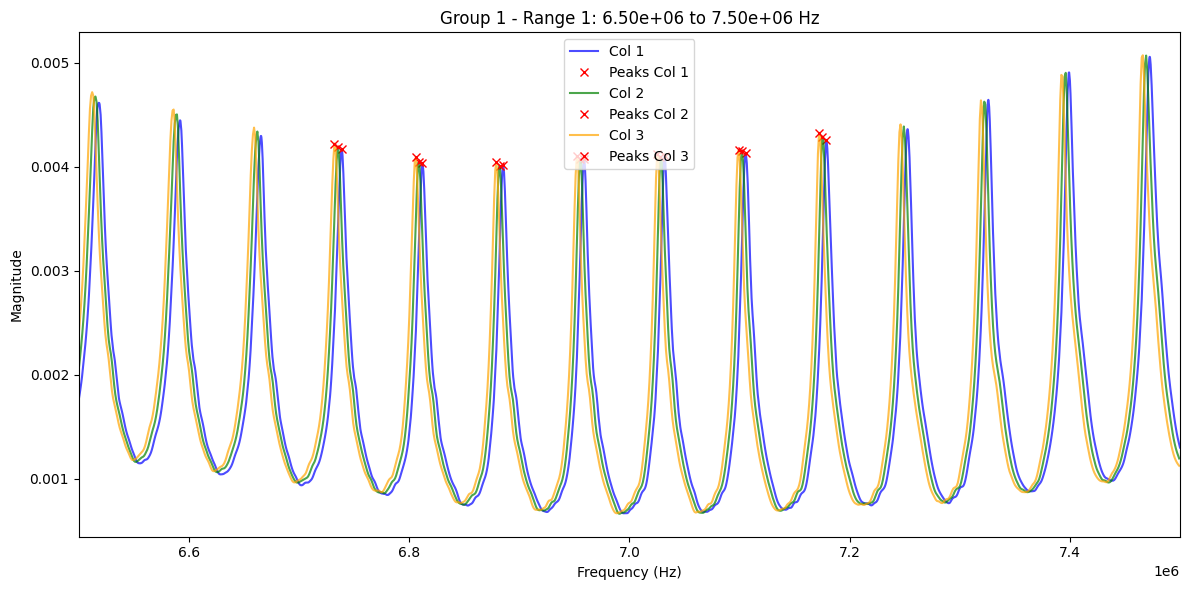

In [ ]:
def main():
    data_folder = r'/content/drive/MyDrive/SFAI on DI Water UMB/CleanData'
    save_dir = r'/content/drive/MyDrive/SFAI on DI Water UMB/Results'
    os.makedirs(save_dir, exist_ok=True)

    column_groups = [

       [1,2],
       [3]



    ]

    group_ranges = [

        [(0.65,0.75)],
        [(0.64,0.75)]

    ]

    group_ranges_e7 = [
        [(start * 1e7, end * 1e7) for (start, end) in group]
        for group in group_ranges
    ]
    group_ranges = group_ranges_e7

    for g_idx, group_cols in enumerate(column_groups):
        print(f"\n--- Processing Group {g_idx+1}: Columns {group_cols} ---")
        ranges = group_ranges[g_idx]
        group_plot_data = []

        for col_idx in group_cols:
            real_idx = col_idx
            convolved_file = os.path.join(data_folder, f"DI_Water_col{real_idx}_convolved.dat") #"Sample10_col{real_idx}_convolved.dat"
            try:
                freqs, mags = np.loadtxt(convolved_file, unpack=True)
            except Exception as e:
                print(f"Failed to read file for Column {real_idx}: {e}")
                continue

            print(f"\n--- Peak width analysis for Column {real_idx} ---")
            all_results = []

            for i, freq_range in enumerate(ranges):
                print(f"\n--- Analyzing range {i+1}: {freq_range} ---")
                peaks, widths, lefts, rights, fs, ms, hhs, lbs, deltas, pfreqs = analyze_convolved_peaks(freqs, mags, freq_range)

                if len(pfreqs) == 0:
                    print(f"    No peaks found in range {freq_range}")
                    continue

                all_results.append((pfreqs, widths))

            if all_results:
                output_filename = os.path.join(save_dir, f"convolved_col{real_idx}_results.dat")
                save_results(output_filename, all_results)

            all_pfreqs = []
            for freq_range in ranges:
                _, _, _, _, _, _, _, _, _, pfreqs = analyze_convolved_peaks(freqs, mags, freq_range)
                all_pfreqs.extend(pfreqs)

            group_plot_data.append((freqs, mags, np.array(all_pfreqs)))

        plot_peaks_group_by_range(group_plot_data, g_idx, ranges)

if __name__ == "__main__":
    main()